Dado que el entrenamiento de redes neuronales es una tarea  muy costosa, **se recomienda ejecutar el notebooks en [Google Colab](https://colab.research.google.com)**, por supuesto también se puede ejecutar en local.

Al entrar en [Google Colab](https://colab.research.google.com) bastará con hacer click en `upload` y subir este notebook. No olvide luego descargarlo en `File->Download .ipynb`

**El examen deberá ser entregado con las celdas ejecutadas, si alguna celda no está ejecutadas no se contará.**

El examen se divide en dos partes, con la puntuación que se indica a continuación. La puntuación máxima será 10.

- [Actividad 1: Redes Densas](#actividad_1): 5 pts
    - Correcta normalización: máximo de 0.25 pts
    - [Cuestión 1](#1.1): 1.5 pt
    - [Cuestión 2](#1.2): 1.5 pt
    - [Cuestión 3](#1.3): 0.5 pts
    - [Cuestión 4](#1.4): 0.25 pts
    - [Cuestión 5](#1.5): 0.25 pts
    - [Cuestión 6](#1.6): 0.25 pts
    - [Cuestión 7](#1.7): 0.25 pts
    - [Cuestión 8](#1.8): 0.25 pts


- [Actividad 2: Redes Convolucionales](#actividad_2): 5 pts
    - [Cuestión 1](#2.1): 2.5 pt
    - [Cuestión 2](#2.2): 1 pt
    - [Cuestión 3](#2.3): 0.5 pts
    - [Cuestión 4](#2.4): 0.5 pts
    - [Cuestión 5](#2.5): 0.5 pts
    

In [1]:
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import random
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)
keras.utils.set_random_seed(0)

<a name='actividad_1'></a>
# Actividad 1: Redes Densas

Para esta primera actividad vamos a utilizar el [California Housing Dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset). Con el que trataremos de predecir el precio mediano de las viviendas en diferentes distritos de California.

El precio de las viviendas es un valor continuo que está expresado en cientos de miles de dólares (por ejemplo, un valor de 2.5 significa $250,000). Por lo tanto, el problema es una `regresión`.

**Features del dataset:**
- MedInc: Ingreso mediano del distrito
- HouseAge: Edad mediana de las casas
- AveRooms: Promedio de habitaciones por vivienda
- AveBedrms: Promedio de dormitorios por vivienda
- Population: Población del distrito
- AveOccup: Promedio de ocupantes por vivienda
- Latitude: Latitud
- Longitude: Longitud


**Puntuación**:

Normalizar las features correctamente (x_train, x_test): 0.25 pts , se pueden normalizar con el [Normalization layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/Normalization) de Keras.


- Correcta normalización: máximo de 0.25 pts
- [Cuestión 1](#1.1): 1.5 pt
- [Cuestión 2](#1.2): 1.5 pt
- [Cuestión 3](#1.3): 0.5 pts
- [Cuestión 4](#1.4): 0.25 pts
- [Cuestión 5](#1.5): 0.25 pts
- [Cuestión 6](#1.6): 0.25 pts
- [Cuestión 7](#1.7): 0.25 pts
- [Cuestión 8](#1.8): 0.25 pts

In [2]:
# Cargar el dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Mostrar información básica
print(f"Tamaño del dataset: {df.shape}")
print(f"Rango de precios: ${df['MedHouseVal'].min():.1f}k - ${df['MedHouseVal'].max():.1f}k")
print("\nPrimeras 5 filas:")
df.head()

Tamaño del dataset: (20640, 9)
Rango de precios: $0.1k - $5.0k

Primeras 5 filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# separar features y target
y = df.pop('MedHouseVal').values
X = df.copy().values

In [7]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print('x_train, y_train shapes:', x_train.shape, y_train.shape)
print('x_test, y_test shapes:', x_test.shape, y_test.shape)
print('Some prices: ', y_train[:5])

x_train, y_train shapes: (15480, 8) (15480,)
x_test, y_test shapes: (5160, 8) (5160,)
Some prices:  [3.813   3.293   1.854   5.00001 0.975  ]


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(x_train)
X_test_norm = scaler.transform(x_test)
print('X_train mu, sigma', X_train_norm.mean(0), X_train_norm.std(0))
print('X_test mu, sigma', X_test_norm.mean(0), X_test_norm.std(0))

X_train mu, sigma [-1.67229710e-14 -8.88034980e-17  3.58860228e-15  5.96632388e-15
  8.26463503e-17 -2.03166690e-15  4.19418735e-14 -9.27362694e-14] [1. 1. 1. 1. 1. 1. 1. 1.]
X_test mu, sigma [-0.00838269  0.0032455  -0.00555645  0.00737486 -0.00281136  0.01973317
  0.00887227 -0.00711079] [1.01086856 0.99549001 0.90237427 0.83421409 0.95717564 2.59969849
 0.99574911 0.99477786]


<a name='1.1'></a>
## Cuestión 1: Cree un modelo secuencial que contenga 4 capas ocultas(hidden layers), con más de 60 neuronas  por capa, sin regularización y obtenga los resultados.

In [22]:
def plot_history(history: tf.keras.callbacks.History) -> None:
    """Plot training and validation loss/metric curves.

    Args:
        history: History object returned by model.fit()
    """
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.plot(hist['epoch'], hist['loss'], label='Train Loss')
    ax1.plot(hist['epoch'], hist['val_loss'], label='Validation Loss')
    ax1.legend()
    ax1.grid(True)

    # Metric plot (MAE in this case)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Mean Absolute Error (MAE)')
    ax2.plot(hist['epoch'], hist['mae'], label='Train MAE')
    ax2.plot(hist['epoch'], hist['val_mae'], label='Validation MAE')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [18]:
model = keras.Sequential()
model.add(layers.Dense(64, input_shape=(x_train.shape[1],), activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='linear'))

## model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,121 (51.25 KB)

 Trainable params: 13,121 (51.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compilación del modelo
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.MSE,
    metrics=['mae']
)

In [20]:
history = model.fit(X_train_norm,
          y_train,
          epochs=60,
          batch_size=32,
          validation_split=0.2,
          verbose=1)

Epoch 1/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.7798 - mae: 0.5994 - val_loss: 0.3908 - val_mae: 0.4709
Epoch 2/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3799 - mae: 0.4372 - val_loss: 0.3588 - val_mae: 0.4485
Epoch 3/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3529 - mae: 0.4182 - val_loss: 0.3425 - val_mae: 0.4347
Epoch 4/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3334 - mae: 0.4044 - val_loss: 0.3319 - val_mae: 0.4277
Epoch 5/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3210 - mae: 0.3954 - val_loss: 0.3220 - val_mae: 0.4177
Epoch 6/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3108 - mae: 0.3878 - val_loss: 0.3137 - val_mae: 0.4091
Epoch 7/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3045 - mae: 0.3827 - val_loss: 0.3091 - val_mae: 0.4041
Epoch 8/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2989 - mae: 0.3781 - val_loss: 0.3069 - val_mae: 0.3998
Epoch 9/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - lo

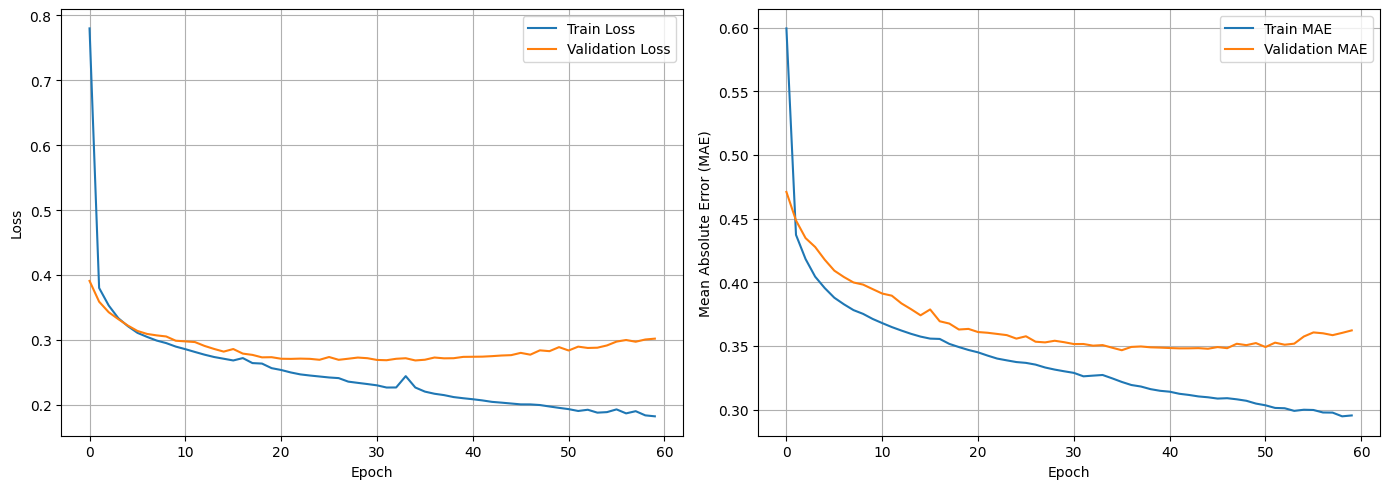

In [23]:
plot_history(history)

In [16]:
# No modifique el código
results = model.evaluate(X_test_norm, y_test, verbose=1)
test_metrics = dict(zip(model.metrics_names, results))
print('Test Metrics:', test_metrics)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3081 - mae: 0.3594
Test Metrics: {'loss': 0.308101624250412, 'compile_metrics': 0.3594099283218384}


Podemos ver como en el gráfico como hay un ligero sobreajuste, por lo tanto el siguiente ejercicio nos va a venir muy bien para ver como mejora el uso de técnicas de regulación para evitar sobreajuste.

<a name='1.2'></a>
## Cuestión 2: Utilice el mismo modelo de la cuestión anterior pero añadiendo al menos dos técnicas distinas de regularización. No es necesario reducir el `test loss`.

Ejemplos de regularización: [Prevent_Overfitting.ipynb](https://github.com/ezponda/intro_deep_learning/blob/main/class/Fundamentals/Prevent_Overfitting.ipynb)

In [ ]:
model = tf.keras.models.Sequential()
# Código aquí
...

In [ ]:
# Compilación del modelo
# Código aquí
model.compile(...)

In [ ]:
batch_size=...

In [ ]:
model.fit(x_train,
          y_train,
          epochs=60,
          batch_size=batch_size,
          validation_split=0.2,
          verbose=1)

In [ ]:
# No modifique el código
results = model.evaluate(x_test, y_test, verbose=1)
test_metrics = dict(zip(model.metrics_names, results))
print('Test Metrics:', test_metrics)

<a name='1.3'></a>
## Cuestión 3: Utilice el mismo modelo de la cuestión anterior pero añadiendo un callback de early stopping.  No es necesario reducir el `test loss`.

In [ ]:
model = tf.keras.models.Sequential()
# Código aquí
...

In [ ]:
# Compilación del modelo
# Código aquí
model.compile(...)

In [ ]:
## definir el early stopping callback
# Código aquí
...
model.fit(x_train,
          y_train,
          epochs=60,
          batch_size=32,
          validation_split=0.2,
          verbose=1,
          callbacks=[...]) # Código aquí

In [ ]:
# No modifique el código
results = model.evaluate(x_test, y_test, verbose=1)
test_metrics = dict(zip(model.metrics_names, results))
print('Test Metrics:', test_metrics)

<a name='1.4'></a>
## Cuestión 4: ¿Podría haberse usado otra función de activación de la neurona de salida? En caso afirmativo especifíquela.

(Escriba: "No" o "Sí, [nombre de la función]")


**Respuesta:**


**Justificación o aclaración (opcional):**

<a name='1.5'></a>
## Cuestión 5:  ¿Qué es lo que una neurona calcula?

**a)** Una función de activación seguida de una suma ponderada  de las entradas.

**b)** Una suma ponderada  de las entradas seguida de una función de activación.

**c)** Una función de pérdida, definida sobre el target.

**d)** Ninguna  de las anteriores es correcta


(Escriba solo la letra: a, b, c o d)

**Respuesta:**

**Justificación o aclaración (opcional):**

<a name='1.6'></a>
## Cuestión 6:  ¿Cuál de estas funciones de activación no debería usarse en una capa oculta (hidden layer)?

**a)** `sigmoid`

**b)** `tanh`

**c)** `relu`

**d)** `linear`


(Escriba solo la letra: a, b, c o d)

**Respuesta:**

**Justificación o aclaración (opcional):**

<a name='1.7'></a>
## Cuestión 7:  ¿Cuál de estas técnicas es efectiva para combatir el overfitting en una red con varias capas ocultas? Ponga todas las que lo sean.

**a)** Dropout

**b)** Regularización L2.

**c)** Aumentar el tamaño del test set.

**d)** Aumentar el tamaño del validation set.

**e)** Reducir el número de capas de la red.

**f)** Data augmentation.

(Escriba las letras separadas por comas. Ejemplo: a, b, e)


**Respuesta:**

**Justificación o aclaración (opcional):**

<a name='1.8'></a>
## Cuestión 8:  Supongamos que queremos entrenar una red para un problema de clasificación de imágenes con las siguientes clases: {'perro','gato','persona'}. ¿Cuántas neuronas y que función de activación debería tener la capa de salida? ¿Qué función de pérdida (loss function) debería usarse?


**Respuesta:**
- Número de neuronas:
- Función de activación:
- Loss function:

**Justificación o aclaración (opcional):**

<a name='actividad_2'></a>
# Actividad 2: Redes Convolucionales

Vamos a usar el dataset [cifar-10](https://www.cs.toronto.edu/~kriz/cifar.html), que son 60000 imágenes de 32x32 a color  con 10 clases diferentes. Para realizar mejor la práctica puede consultar [Introduction_to_CNN.ipynb](https://github.com/ezponda/intro_deep_learning/blob/main/class/CNN/Introduction_to_CNN.ipynb).



**Puntuación**:

- [Cuestión 1](#2.1): 2.5 pt
- [Cuestión 2](#2.2): 1 pt
- [Cuestión 3](#2.3): 0.5 pts
- [Cuestión 4](#2.4): 0.5 pts
- [Cuestión 5](#2.5): 0.5 pts

Puede normalizar las imágenes al principio o usar la capa [Rescaling](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/Rescaling):

```python
tf.keras.layers.experimental.preprocessing.Rescaling(
    scale, offset=0.0, name=None, **kwargs
)
```

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [ ]:
print('x_train, y_train shapes:', x_train.shape, y_train.shape)
print('x_test, y_test shapes:', x_test.shape, y_test.shape)

<a name='2.1'></a>
## Cuestión 1: Cree una red convolucional con la API funcional con al menos dos capas convolucionales y al menos dos capas de pooling. Debe obtener un `Test accuracy > 0.70`

In [ ]:
inputs = tf.keras.Input(shape=..., name='input')
# reescaling = ...

# Convolution + pooling layers
...

# Flattening
...

# Fully-connected
outputs = layers.Dense(...)

model = keras.Model(inputs=..., outputs=...)

In [ ]:
model.compile(
    optimizer='adam',
    loss=...,
    metrics=[...],
    )

In [ ]:
# (Opcional) si quiere, puede definir un callback para early stopping
# early_stopping = ...

In [ ]:
history = model.fit(x_train, y_train, epochs=25, batch_size=64,
                    validation_split=0.15)

In [ ]:
# No modifique el código
results = model.evaluate(x_test, y_test, verbose=1)

test_metrics = dict(zip(model.metrics_names, results))
for metric in model.metrics_names:
    print(f"test_{metric}: {test_metrics[metric]}")

<a name='2.2'></a>
## Cuestión 2: Cree el mismo  modelo de manera secuencial. No es necesario compilar ni entrenar el modelo

In [ ]:
model_seq = tf.keras.models.Sequential()
# Código aquí
...

<a name='2.3'></a>
## Cuestión 3: Si tenenemos una  una imagen de entrada de 300 x 300 a color (RGB) y queremos usar una red densa. Si la primera capa oculta tiene 100 neuronas, ¿Cuántos parámetros tendrá esa capa (sin incluir el bias) ?


(Escriba solo el número)

**Respuesta:**

**Justificación o aclaración (opcional):**

<a name='2.4'></a>
## Cuestión 4   Ponga  las verdaderas ventajas de las redes convolucionales respecto a las densas

**a)** Reducen el número total de parámetros, reduciendo así el overfitting.

**b)** Permiten utilizar una misma 'función'  en varias localizaciones de la imagen de entrada, en lugar de aprender una función diferente para cada pixel.

**c)** Permiten el uso del transfer learning.

**d)** Generalmente son menos profundas, lo que facilita su entrenamiento.



(Escriba las letras separadas por comas. Ejemplo: a, b)

**Respuesta:**

**Justificación o aclaración (opcional):**

<a name='2.5'></a>
## Cuestión 5: Para el procesamiento de series temporales las redes convolucionales no son efectivas, habrá que usar redes recurrentes.

- **Verdadero**
- **Falso**

(Escriba: Verdadero o Falso)

**Respuesta:**

**Justificación o aclaración (opcional):**